# Adição de Ruído ao Dataset do Alimentador

Implementa os 4 modelos de incerteza descritos no artigo 

*"PMU-Based State Estimation: A Multisnapshot Approach for Mitigating the Impact of Systematic Errors and Line Parameters Uncertainty"*

| Grandeza | Fonte | Tipo | Limites |
|---|---|---|---|
| Parâmetros de linha (r, x) | Incerteza de parâmetros | Retangular ±15% relativo | Constante no tempo |
| Magnitude de tensão | PMU + TP | Retangular ±0,2% + ±1% | Independente por amostra |
| Ângulo de tensão | PMU + TP | Retangular ±0,2 crad + ±1,2 crad | Independente por amostra |
| Magnitude de corrente | PMU + TC | Retangular ±0,2% + ±1% | Independente por amostra |
| Ângulo de corrente | PMU + TC | Retangular ±0,2 crad + ±1,8 crad | Independente por amostra |
| Potências P, Q | Variação de carga | Retangular ±20% | Independente por amostra |

> **Convenção angular**: ângulos no dataset estão em **graus**.  
> Conversão: 1 crad = 0,01 rad = 0,01 × 180/π ≈ **0,5730°**

> **Erros PMU e TI são independentes** — a PMU mede a saída do transformador de instrumentos,  
> portanto o erro total é a **soma** das duas fontes.

In [11]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

# Conversão crad → graus
CRAD_TO_DEG = 0.01 * 180 / math.pi   # ≈ 0.5730 °/crad

df = pd.read_csv('Dados14barras/resultados_completos_0.01.csv')
N  = len(df)

print(f'Shape: {df.shape}')
df.head(3)

Shape: (10000, 48)


,r11,r12,r22,r13,r23,r33,x11,x12,x22,x13,...,I1_mag_faseB,I1_ang_faseB,I1_mag_faseC,I1_ang_faseC,I2_mag_faseA,I2_ang_faseA,I2_mag_faseB,I2_ang_faseB,I2_mag_faseC,I2_ang_faseC
0,0.347844,0.155813,0.334539,0.158830,0.151783,0.343622,1.032914,0.492856,1.061910,0.423621,...,419.460,-141.40,591.660,93.41,563.059,151.19,419.461,38.60,591.661,-86.59
1,0.347276,0.156226,0.341095,0.157745,0.154151,0.342203,1.010191,0.493998,1.033069,0.423300,...,419.207,-141.27,591.786,93.41,562.323,151.35,419.207,38.73,591.786,-86.59
2,0.342861,0.155914,0.336783,0.157673,0.151452,0.344504,1.032487,0.495806,1.041401,0.424497,...,419.235,-141.34,592.082,93.36,562.830,151.20,419.235,38.66,592.083,-86.64


## 1. Agrupamento das colunas por tipo de grandeza

In [12]:
# Targets: parâmetros de linha (conservados como ground-truth da estimação)
PARAM_COLS = ['r11','r12','r22','r13','r23','r33',
              'x11','x12','x22','x13','x23','x33']

# PMU + TP: tensões
V_MAG_COLS = ['V1_mag_RG60','V2_mag_RG60','V3_mag_RG60',
              'V1_mag_632', 'V2_mag_632', 'V3_mag_632']
V_ANG_COLS = ['V1_ang_RG60','V2_ang_RG60','V3_ang_RG60',
              'V1_ang_632', 'V2_ang_632', 'V3_ang_632']

# PMU + TC: correntes
I_MAG_COLS = ['I1_mag_faseA','I1_mag_faseB','I1_mag_faseC',
              'I2_mag_faseA','I2_mag_faseB','I2_mag_faseC']
I_ANG_COLS = ['I1_ang_faseA','I1_ang_faseB','I1_ang_faseC',
              'I2_ang_faseA','I2_ang_faseB','I2_ang_faseC']

# Potências (±20% variação de carga)
P_COLS = ['P1_faseA','P1_faseB','P1_faseC','P2_faseA','P2_faseB','P2_faseC']
Q_COLS = ['Q1_faseA','Q1_faseB','Q1_faseC','Q2_faseA','Q2_faseB','Q2_faseC']

## 2. Modelos matemáticos dos ruídos

### 2.1 Distribuição de base — Uniforme Retangular

Todos os erros seguem distribuições uniformes simétricas com **valor esperado nulo**:

$$\varepsilon \sim \mathcal{U}(-\Delta,\, +\Delta)$$

| Estatística | Expressão |
|---|---|
| Esperança | $E[\varepsilon] = 0$ |
| Variância | $\mathrm{Var}[\varepsilon] = \dfrac{\Delta^2}{3}$ |
| Desvio-padrão | $\sigma_\varepsilon = \dfrac{\Delta}{\sqrt{3}}$ |

---

### 2.2 Parâmetros de linha — resistências e reatâncias

Os erros são **relativos** e amostrados **uma única vez** por parâmetro, permanecendo **constantes em todos os instantes** de tempo:

$$\boxed{\hat{p}_k = p_k^{\mathrm{nom}}\,\bigl(1 + \varepsilon_k^{p}\bigr)}$$

$$\varepsilon_k^{p} \sim \mathcal{U}\!\left(-\Delta p_{\max},\, +\Delta p_{\max}\right), \qquad \Delta p_{\max} = 0{,}15 \; (15\%)$$

$$\sigma_{\hat{p}_k} = \frac{0{,}15}{\sqrt{3}}\;p_k^{\mathrm{nom}} \approx 8{,}66\%\cdot p_k^{\mathrm{nom}}$$

> $k \in \{r_{11}, r_{12}, r_{22}, r_{13}, r_{23}, r_{33},\; x_{11}, x_{12}, x_{22}, x_{13}, x_{23}, x_{33}\}$

---

### 2.3 Cadeia de medição PMU — dois erros independentes

A PMU mede o sinal já condicionado pelo Transformador de Instrumentos (TI).  
O erro total é a **soma** de dois erros independentes:

$$\varepsilon^{\mathrm{total}} = \varepsilon^{\mathrm{PMU}} + \varepsilon^{\mathrm{TI}}$$

Por independência, as variâncias se somam:

$$\mathrm{Var}\!\left[\varepsilon^{\mathrm{total}}\right] = \frac{\Delta_{\mathrm{PMU}}^2 + \Delta_{\mathrm{TI}}^2}{3} \qquad \Rightarrow \qquad \sigma^{\mathrm{total}} = \sqrt{\frac{\Delta_{\mathrm{PMU}}^2 + \Delta_{\mathrm{TI}}^2}{3}}$$

A distribuição resultante é **trapezoidal simétrica** com suporte $\bigl[-(\Delta_{\mathrm{PMU}}+\Delta_{\mathrm{TI}}),\; +(\Delta_{\mathrm{PMU}}+\Delta_{\mathrm{TI}})\bigr]$.

---

### 2.4 Magnitude de tensão — PMU + Transformador de Potencial (TP)

O erro de razão é **relativo** (multiplicativo):

$$\boxed{\hat{V} = V\,\bigl(1 + \varepsilon_{\mathrm{PMU}}^{|V|} + \varepsilon_{\mathrm{TP}}^{|V|}\bigr)}$$

$$\varepsilon_{\mathrm{PMU}}^{|V|} \sim \mathcal{U}(-0{,}002,\; +0{,}002) \qquad \varepsilon_{\mathrm{TP}}^{|V|} \sim \mathcal{U}(-0{,}01,\; +0{,}01)$$

$$\sigma_{\hat{V}} = V\,\sqrt{\frac{(0{,}002)^2 + (0{,}01)^2}{3}} = V\,\sqrt{\frac{1{,}04\times10^{-4}}{3}} \approx 0{,}589\%\cdot V$$

---

### 2.5 Ângulo de tensão — PMU + TP

O erro de fase é **absoluto** (aditivo), em centiradianos (crad):
$$1\,\mathrm{crad} = 0{,}01\,\mathrm{rad} \approx 0{,}5730°$$

$$\boxed{\hat{\theta}_V = \theta_V + \varepsilon_{\mathrm{PMU}}^{\angle V} + \varepsilon_{\mathrm{TP}}^{\angle V}}$$

$$\varepsilon_{\mathrm{PMU}}^{\angle V} \sim \mathcal{U}(-0{,}2\,\mathrm{crad},\; +0{,}2\,\mathrm{crad}) \qquad \varepsilon_{\mathrm{TP}}^{\angle V} \sim \mathcal{U}(-1{,}2\,\mathrm{crad},\; +1{,}2\,\mathrm{crad})$$

$$\sigma_{\hat{\theta}_V} = \sqrt{\frac{(0{,}2)^2+(1{,}2)^2}{3}} \approx 0{,}703\,\mathrm{crad} \approx 0{,}402°$$

---

### 2.6 Magnitude de corrente — PMU + Transformador de Corrente (TC)

$$\boxed{\hat{I} = I\,\bigl(1 + \varepsilon_{\mathrm{PMU}}^{|I|} + \varepsilon_{\mathrm{TC}}^{|I|}\bigr)}$$

$$\varepsilon_{\mathrm{PMU}}^{|I|} \sim \mathcal{U}(-0{,}002,\; +0{,}002) \qquad \varepsilon_{\mathrm{TC}}^{|I|} \sim \mathcal{U}(-0{,}01,\; +0{,}01)$$

$$\sigma_{\hat{I}} = I\,\sqrt{\frac{(0{,}002)^2+(0{,}01)^2}{3}} \approx 0{,}589\%\cdot I$$

---

### 2.7 Ângulo de corrente — PMU + TC

$$\boxed{\hat{\theta}_I = \theta_I + \varepsilon_{\mathrm{PMU}}^{\angle I} + \varepsilon_{\mathrm{TC}}^{\angle I}}$$

$$\varepsilon_{\mathrm{PMU}}^{\angle I} \sim \mathcal{U}(-0{,}2\,\mathrm{crad},\; +0{,}2\,\mathrm{crad}) \qquad \varepsilon_{\mathrm{TC}}^{\angle I} \sim \mathcal{U}(-1{,}8\,\mathrm{crad},\; +1{,}8\,\mathrm{crad})$$

$$\sigma_{\hat{\theta}_I} = \sqrt{\frac{(0{,}2)^2+(1{,}8)^2}{3}} \approx 1{,}046\,\mathrm{crad} \approx 0{,}599°$$

---

### 2.8 Potências ativas e reativas — variação de carga

$$\boxed{\hat{P} = P\,(1 + \varepsilon^P), \qquad \hat{Q} = Q\,(1 + \varepsilon^Q)}$$

$$\varepsilon^P,\; \varepsilon^Q \sim \mathcal{U}(-0{,}20,\; +0{,}20)$$

$$\sigma_{\hat{P}} = \frac{0{,}20}{\sqrt{3}}\,P \approx 11{,}55\%\cdot P \qquad \sigma_{\hat{Q}} = \frac{0{,}20}{\sqrt{3}}\,Q \approx 11{,}55\%\cdot Q$$

---

### Quadro resumo

| Grandeza | Fonte | $\Delta_{\max}$ combinado | $\sigma$ combinado |
|---|---|---|---|
| $r,\,x$ | Catálogo | $\pm 15\%$ | $\approx 8{,}66\%$ |
| $\lvert V\rvert$ | PMU + TP | $\pm 1{,}2\%$ | $\approx 0{,}589\%$ |
| $\angle V$ | PMU + TP | $\pm 1{,}4\,\mathrm{crad} = \pm 0{,}802°$ | $\approx 0{,}402°$ |
| $\lvert I\rvert$ | PMU + TC | $\pm 1{,}2\%$ | $\approx 0{,}589\%$ |
| $\angle I$ | PMU + TC | $\pm 2{,}0\,\mathrm{crad} = \pm 1{,}146°$ | $\approx 0{,}599°$ |
| $P,\,Q$ | Variação de carga | $\pm 20\%$ | $\approx 11{,}55\%$ |

## 3. Aplicação do ruído

Implementação das equações da seção 2. Cada erro é amostrado independentemente;  
o erro combinado PMU + TI é obtido somando as duas amostras uniformes.

In [13]:
df_noisy = df.copy()

# ─── Limites numéricos ─────────────────────────────────────────────────────
PMU_MAG  = 0.002          # ±0,2 % (relativo)
TP_MAG   = 0.010          # ±1,0 % relativo (TP)
TC_MAG   = 0.010          # ±1,0 % relativo (TC)

# Convertidos para graus
PMU_ANG_DEG = 0.2 * CRAD_TO_DEG   # ±0,2 crad ≈ ±0,1146°
TP_ANG_DEG  = 1.2 * CRAD_TO_DEG   # ±1,2 crad ≈ ±0,6875°
TC_ANG_DEG  = 1.8 * CRAD_TO_DEG   # ±1,8 crad ≈ ±1,0313°

PQ_VAR = 0.20             # ±20 % (variação de carga)

def unif(bound, size):
    """Amostra uniforme centrada em zero com semi-amplitude `bound`."""
    return rng.uniform(-bound, bound, size)


# ─── (a) Magnitude de tensão: PMU ±0,2 % + TP ±1 % ──────────────────────
for col in V_MAG_COLS:
    df_noisy[col] = df[col] * (1 + unif(PMU_MAG, N) + unif(TP_MAG, N))

# ─── (b) Ângulo de tensão: PMU ±0,2 crad + TP ±1,2 crad [em graus] ───────
for col in V_ANG_COLS:
    df_noisy[col] = df[col] + unif(PMU_ANG_DEG, N) + unif(TP_ANG_DEG, N)

# ─── (c) Magnitude de corrente: PMU ±0,2 % + TC ±1 % ────────────────────
for col in I_MAG_COLS:
    df_noisy[col] = df[col] * (1 + unif(PMU_MAG, N) + unif(TC_MAG, N))

# ─── (d) Ângulo de corrente: PMU ±0,2 crad + TC ±1,8 crad [em graus] ─────
for col in I_ANG_COLS:
    df_noisy[col] = df[col] + unif(PMU_ANG_DEG, N) + unif(TC_ANG_DEG, N)

# ─── (e) Potências P e Q: ±20 % ─────────────────────────────────────────
for col in P_COLS + Q_COLS:
    df_noisy[col] = df[col] * (1 + unif(PQ_VAR, N))

# ─── (f) Parâmetros de linha: ±15 %, CONSTANTE sobre os instantes de tempo ─
#
# Um único vetor de ruído é amostrado para todos os 12 parâmetros;
# o mesmo valor é aplicado a todas as N linhas, pois os parâmetros físicos
# do cabo não mudam ao longo do tempo de medição.
#
# Nota: no dataset, os valores de r/x já são o ground-truth utilizado
# na simulação de fluxo de potência.  A coluna '_noisy' representa o
# valor que um operador estimaria a partir do catálogo + incerteza de ±15 %.
PARAM_NOISE = 0.15   # ±15 % relativo
param_nominal = df[PARAM_COLS].mean()   # valor nominal = média do dataset
delta_params  = rng.uniform(-PARAM_NOISE, PARAM_NOISE, len(PARAM_COLS))

for i, col in enumerate(PARAM_COLS):
    noisy_val = float(param_nominal[col] * (1 + delta_params[i]))
    df_noisy[col + '_noisy'] = noisy_val   # nova coluna; r/x originais preservados

print('Ruído aplicado com sucesso.')
print(f'Colunas originais: {df.shape[1]}  |  Novas colunas (param_noisy): {len(PARAM_COLS)}')
print(f'Shape final: {df_noisy.shape}')

Ruído aplicado com sucesso.
Colunas originais: 48  |  Novas colunas (param_noisy): 12
Shape final: (10000, 60)


## 4. Verificação estatística dos erros introduzidos

In [14]:
records = []

def check(cols, kind):
    for col in cols:
        clean = df[col].values
        noisy = df_noisy[col].values
        if 'ang' in col.lower() or 'ang' in kind.lower():
            err = noisy - clean           # erro absoluto (graus)
            unit = '°'
        else:
            err = (noisy - clean) / np.abs(clean) * 100   # erro relativo (%)
            unit = '%'
        records.append({
            'coluna': col,
            'tipo': kind,
            'erro_max (abs)': f'{np.abs(err).max():.4f} {unit}',
            'erro_mean':       f'{err.mean():.2e} {unit}',
            'erro_std':        f'{err.std():.4f} {unit}',
        })

check(V_MAG_COLS, 'V_mag (PMU+TP)')
check(V_ANG_COLS, 'V_ang (PMU+TP)')
check(I_MAG_COLS, 'I_mag (PMU+TC)')
check(I_ANG_COLS, 'I_ang (PMU+TC)')
check(P_COLS,     'P (±20%)')
check(Q_COLS,     'Q (±20%)')

pd.DataFrame(records)

,coluna,tipo,erro_max (abs),erro_mean,erro_std
0,V1_mag_RG60,V_mag (PMU+TP),1.1892 %,4.72e-03 %,0.5889 %
1,V2_mag_RG60,V_mag (PMU+TP),1.1923 %,4.33e-03 %,0.5912 %
2,V3_mag_RG60,V_mag (PMU+TP),1.1905 %,-6.17e-04 %,0.5914 %
3,V1_mag_632,V_mag (PMU+TP),1.1817 %,9.78e-03 %,0.5843 %
4,V2_mag_632,V_mag (PMU+TP),1.1832 %,-2.56e-03 %,0.5936 %
5,V3_mag_632,V_mag (PMU+TP),1.1909 %,-8.58e-04 %,0.5890 %
6,V1_ang_RG60,V_ang (PMU+TP),0.7995 °,-3.22e-03 °,0.4022 °
7,V2_ang_RG60,V_ang (PMU+TP),0.7943 °,7.86e-03 °,0.4040 °
8,V3_ang_RG60,V_ang (PMU+TP),0.8010 °,-4.98e-03 °,0.4033 °
9,V1_ang_632,V_ang (PMU+TP),0.7930 °,-6.18e-03 °,0.4000 °


In [15]:
# Verificação dos parâmetros de linha ruidosos
print('Desvio relativo do parâmetro ruidoso em relação ao nominal:')
for col in PARAM_COLS:
    nom = float(param_nominal[col])
    val = df_noisy[col + '_noisy'].iloc[0]
    pct = (val - nom) / nom * 100
    print(f'  {col:6s}: nominal={nom:.5f}  ruidoso={val:.5f}  desvio={pct:+.2f}%')

Desvio relativo do parâmetro ruidoso em relação ao nominal:
  r11   : nominal=0.34651  ruidoso=0.35083  desvio=+1.25%
  r12   : nominal=0.15599  ruidoso=0.14937  desvio=-4.25%
  r22   : nominal=0.33751  ruidoso=0.35929  desvio=+6.45%
  r13   : nominal=0.15796  ruidoso=0.16750  desvio=+6.04%
  r23   : nominal=0.15347  ruidoso=0.16101  desvio=+4.91%
  r33   : nominal=0.34142  ruidoso=0.32240  desvio=-5.57%
  x11   : nominal=1.01790  ruidoso=1.02930  desvio=+1.12%
  x12   : nominal=0.50169  ruidoso=0.53225  desvio=+6.09%
  x22   : nominal=1.04786  ruidoso=0.89706  desvio=-14.39%
  x13   : nominal=0.42356  ruidoso=0.45116  desvio=+6.51%
  x23   : nominal=0.38488  ruidoso=0.35468  desvio=-7.85%
  x33   : nominal=1.03485  ruidoso=1.15112  desvio=+11.24%


## 5. Distribuição dos erros de medição

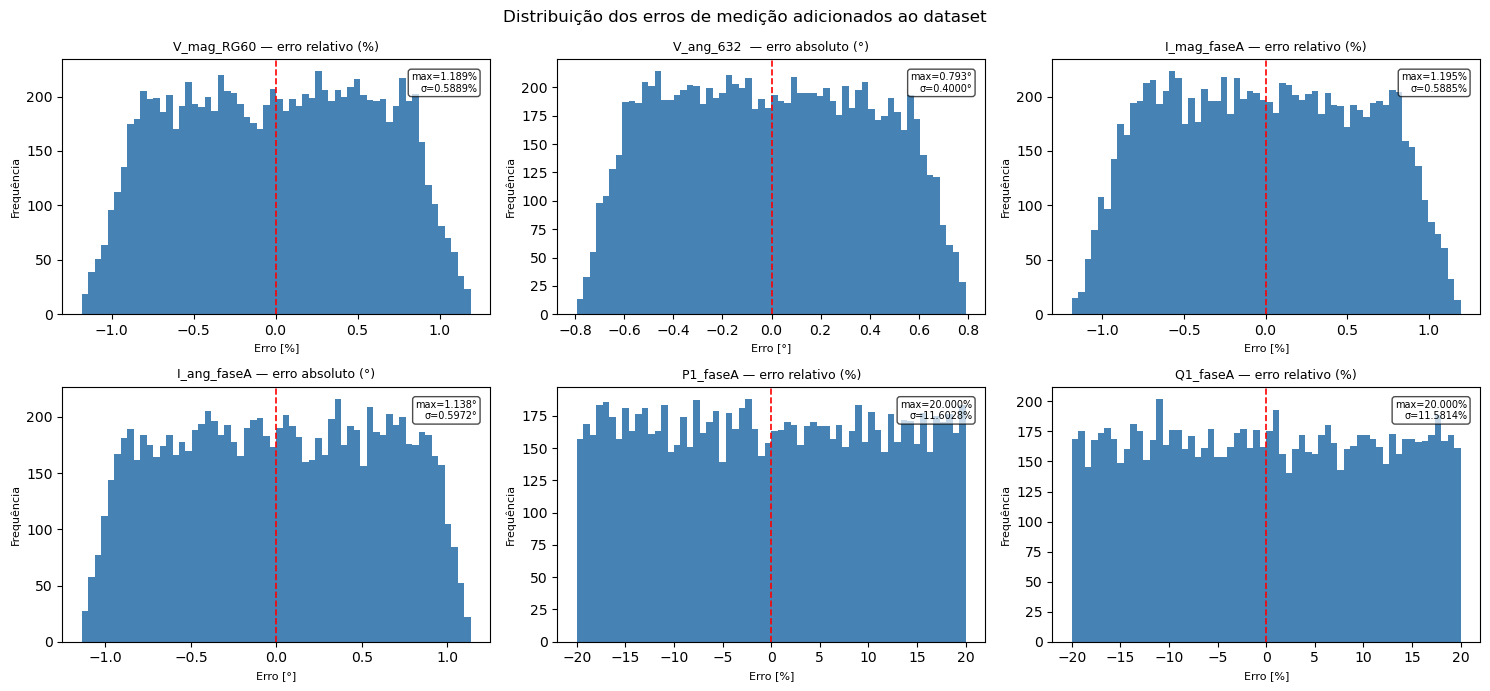

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

plot_cfg = [
    (V_MAG_COLS[0],  'V_mag_RG60 — erro relativo (%)', '%',   lambda c, n: (n-c)/c*100),
    (V_ANG_COLS[3],  'V_ang_632  — erro absoluto (°)', '°',   lambda c, n: n-c),
    (I_MAG_COLS[0],  'I_mag_faseA — erro relativo (%)', '%',  lambda c, n: (n-c)/c*100),
    (I_ANG_COLS[0],  'I_ang_faseA — erro absoluto (°)', '°',  lambda c, n: n-c),
    (P_COLS[0],      'P1_faseA — erro relativo (%)', '%',     lambda c, n: (n-c)/c*100),
    (Q_COLS[0],      'Q1_faseA — erro relativo (%)', '%',     lambda c, n: (n-c)/c*100),
]

for ax, (col, title, unit, fn) in zip(axes, plot_cfg):
    err = fn(df[col].values, df_noisy[col].values)
    ax.hist(err, bins=60, color='steelblue', edgecolor='none')
    ax.axvline(0, color='red', lw=1.2, ls='--')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(f'Erro [{unit}]', fontsize=8)
    ax.set_ylabel('Frequência', fontsize=8)
    ax.text(0.97, 0.95, f'max={np.abs(err).max():.3f}{unit}\nσ={err.std():.4f}{unit}',
            transform=ax.transAxes, ha='right', va='top', fontsize=7,
            bbox=dict(boxstyle='round', fc='white', alpha=0.7))

plt.suptitle('Distribuição dos erros de medição adicionados ao dataset', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Salvar dataset com ruído

In [17]:
out_path = 'Dados14barras/resultados_completos_com_ruido.csv'
df_noisy.to_csv(out_path, index=False)

print(f'Dataset salvo em: {out_path}')
print(f'Shape: {df_noisy.shape}')
print()
print('Colunas adicionadas (parâmetros ruidosos):')
print([c for c in df_noisy.columns if c.endswith('_noisy')])

df_noisy.head(3)

Dataset salvo em: Dados14barras/resultados_completos_com_ruido.csv
Shape: (10000, 60)

Colunas adicionadas (parâmetros ruidosos):
['r11_noisy', 'r12_noisy', 'r22_noisy', 'r13_noisy', 'r23_noisy', 'r33_noisy', 'x11_noisy', 'x12_noisy', 'x22_noisy', 'x13_noisy', 'x23_noisy', 'x33_noisy']


,r11,r12,r22,r13,r23,r33,x11,x12,x22,x13,...,r22_noisy,r13_noisy,r23_noisy,r33_noisy,x11_noisy,x12_noisy,x22_noisy,x13_noisy,x23_noisy,x33_noisy
0,0.347844,0.155813,0.334539,0.158830,0.151783,0.343622,1.032914,0.492856,1.061910,0.423621,...,0.359286,0.167502,0.161011,0.322405,1.029298,0.53225,0.897065,0.451157,0.354676,1.151118
1,0.347276,0.156226,0.341095,0.157745,0.154151,0.342203,1.010191,0.493998,1.033069,0.423300,...,0.359286,0.167502,0.161011,0.322405,1.029298,0.53225,0.897065,0.451157,0.354676,1.151118
2,0.342861,0.155914,0.336783,0.157673,0.151452,0.344504,1.032487,0.495806,1.041401,0.424497,...,0.359286,0.167502,0.161011,0.322405,1.029298,0.53225,0.897065,0.451157,0.354676,1.151118
